In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from quantem.tomography.tomography import TomographyConventional, Tomography
from quantem.tomography.dataset_models import TomographyPixDataset, TomographyINRDataset, TomographyINRPretrainDataset
from quantem.tomography.object_models import ObjectINR, ObjectPixelated
from quantem.tomography.logger_tomography import LoggerTomography
from quantem.core.ml.inr import HSiren
import numpy as np

from quantem.core.utils.tomography_utils import fourier_binning
from quantem.core.visualization import show_2d
import torch

device = 'cuda' # Set device

/home/cedlim/quantem/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
tilt_series = np.load('../../../data/tilt_series.npy')
tilt_angles = np.load('../../../data/tilt_angles.npy')

tilt_series = np.array([fourier_binning(img, (100, 100)) for img in tilt_series]) # Cropped down to 100x100 for speed
    

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

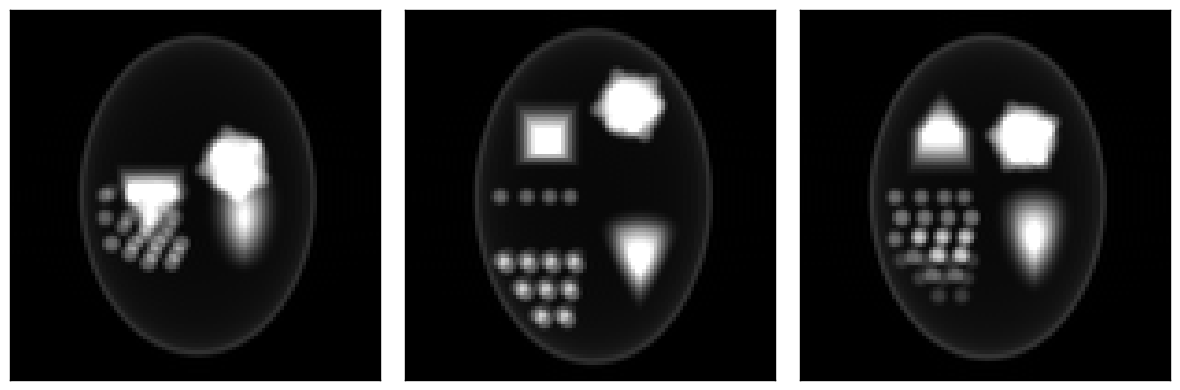

In [4]:
show_2d(
    [tilt_series[0], tilt_series[30], tilt_series[60]],
)

# Conventional Tomography Reconstructions
*Cedric Lim, 2/1/2026*

In [6]:
# Initialize dataset
dset = TomographyPixDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

In [7]:
# Initialize object

obj_pix = ObjectPixelated.from_uniform(
    shape = (100, 100, 100), 
    device = device,
)

In [8]:
# Initialize conventional tomography object

tomo_conv = TomographyConventional.from_models(
    dset = dset,
    obj_model = obj_pix,
    device = device,
)

In [9]:
tomo_conv.reconstruct(
    num_iter = 10,
    inline_alignment = True,
    smoothing_sigma = 0.05,
)

sirt Reconstruction:   0%|          | 0/10 [00:00<?, ?it/s]

proj_forward.shape torch.Size([100, 71, 100])
self.dset.tilt_stack.shape torch.Size([71, 100, 100])


sirt Reconstruction | Loss: 0.0191: 100%|██████████| 10/10 [00:00<00:00, 10.07it/s]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

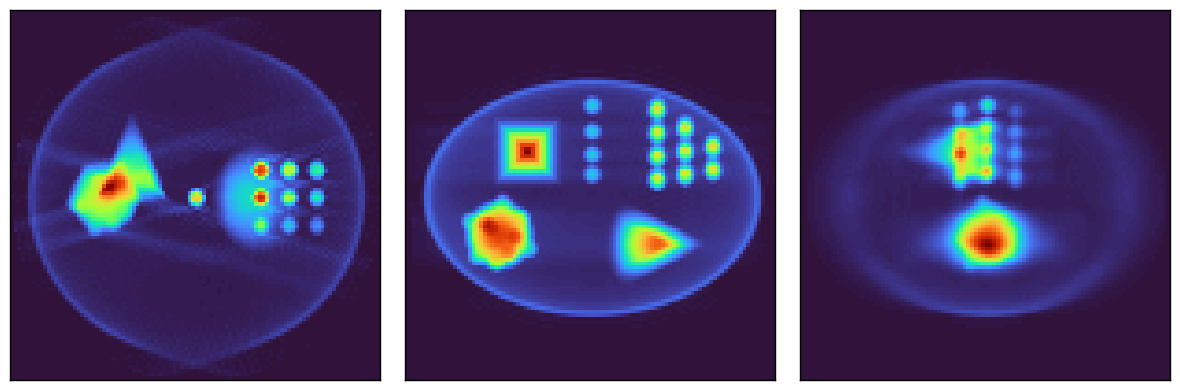

In [10]:
show_2d(
    [obj_pix.obj.sum(axis = 0), obj_pix.obj.sum(axis = 1), obj_pix.obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

# INR-Based Tomography Reconstruction

In [11]:
dset = TomographyINRDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

In [12]:
# Initialize INR Model
model = HSiren(alpha = 1, winner_initialization = True)

# Initialize INR Object
obj_inr = ObjectINR.from_model(
    shape = (100, 100, 100),
    device = device,
    model = model,
)


Model built, compiled successfully


In [13]:
# Define a logger
logger = LoggerTomography(
    log_dir = "../../../outputs/tomography/tutorial_02/",
    run_prefix = "inr_tomography",
    run_suffix = "",
    log_images_every = 2,
)

In [14]:
# Initialize INR-Based Tomography Object
tomo_inr = Tomography.from_models(
    dset = dset,
    obj_model = obj_inr,
    device = device,
    logger = logger,
)

Setting up DDP for obj_model


In [15]:
# Define optimizer and scheduler parameters

optimizer_params = {
    "object": {
        "type": "adam",
        "lr": 1e-4,
    },
    "pose": {
        "type": "adam",
        "lr": 1e-2,
    }
}

scheduler_params = {
    "object": {
        "type": "plateau",
    },
    "pose": {
        "type": "plateau",
    }
}

# Define constraints

obj_constraints = {
    "tv_vol": 1e-5,
    "positivity": True,
    "shrinkage": 1e-6,
}

## Dataset constraints not necessarily needed.
dataset_constraints = {
    "tv_shifts": 1e-6,
    "tv_zs": 1e-6,
}



In [16]:
# Reconstruct

tomo_inr.reconstruct(
    num_iter = 1,
    batch_size = 1024,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    obj_constraints = obj_constraints,
    dset_constraints = dataset_constraints,
    num_samples_per_ray = 100,
    num_workers = 32,
)

Dataloader setup complete:
  Total train samples: 710000
  Local batch size: 1024
  Global batch size: 1024
  Train batches per GPU per epoch: 693


Reconstruction | Loss: 0.0239, Consistency Loss: 0.0237, Soft Constraint Loss: 0.0002 | Logger Updated: 100%|██████████| 1/1 [00:12<00:00, 12.21s/it]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

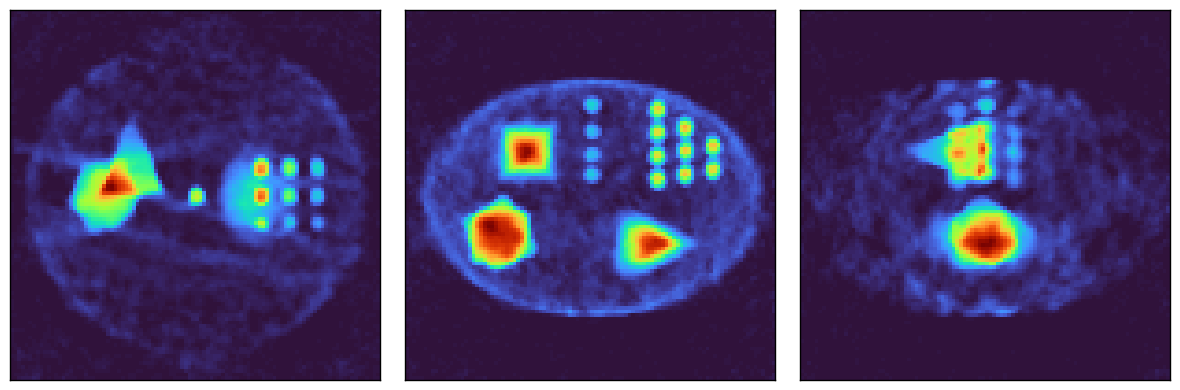

In [17]:
obj_inr.create_volume()
obj = obj_inr.obj.cpu().numpy()[0].transpose(0, 2, 1)

show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

## Continuing Training

If the volume is not converged yet, you can continue training by calling another `.reconstruct` call. Exisiting dataloaders will not be reinitialized

In [18]:
tomo_inr.reconstruct(
    num_iter = 20
)

Reconstruction:   0%|          | 0/20 [00:00<?, ?it/s]

Reconstruction | Loss: 0.0002, Consistency Loss: 0.0002, Soft Constraint Loss: 0.0001 | Logger Updated: 100%|██████████| 20/20 [04:07<00:00, 12.36s/it]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

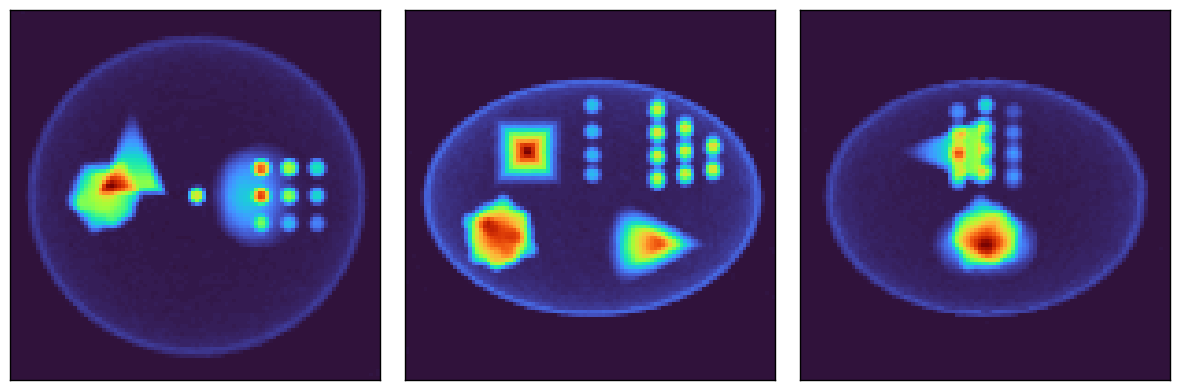

In [19]:
obj_inr.create_volume()
obj = obj_inr.obj.cpu().numpy()[0].transpose(0, 2, 1)

show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

## Training Strategies

For these reconstructions one could implement warmup, different scheduler training, or pretraining strategies. A few examples are shown below

### Warmup to CosineAnneal

In [ ]:
dset = TomographyINRDataset(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

# Initialize INR Model
model = HSiren(alpha = 1, winner_initialization = True)

# Initialize INR Object
obj_inr = ObjectINR.from_model(
    shape = (100, 100, 100),
    device = device,
    model = model,
)

# Define a logger
logger = LoggerTomography(
    log_dir = "../../../outputs/tomography/tutorial_02/",
    run_prefix = "inr_tomography_warmup_cosineanneal",
    run_suffix = "1",
    log_images_every = 2,
)

# Initialize INR-Based Tomography Object
tomo_inr = Tomography.from_models(
    dset = dset,
    obj_model = obj_inr,
    device = device,
    logger = logger,
)

In [ ]:
# Define optimizer and scheduler parameters - only optimizing the object.

optimizer_params = {
    "object": {
        "type": "adam",
        "lr": 1e-4,
    },
}

scheduler_params = {
    "object": {
        "type": "linear",
    },
}

# Define constraints

obj_constraints = {
    "tv_vol": 5e-7,
    "positivity": True,
    "sparsity": 1e-6,
}

dset_constraints = {
    "tv_shifts": 1e-6,
    "tv_zs": 1e-6,
}

# Warmup Schedule for 10 epochs

num_samples_per_ray = [
    (0, 20),
    (1, 20),
    (2, 40),
    (3, 40),
    (4, 60),
    (4, 60),
    (6, 80),
    (7, 80),
    (8, 100),
    (9, 100),
]


In [ ]:
tomo_inr.reconstruct(
    num_iter = 10,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    obj_constraints = obj_constraints,
    dset_constraints = dset_constraints,
    num_samples_per_ray = num_samples_per_ray,
    num_workers = 32,
)


In [ ]:
# Initialzie pose optimizer 

optimizer_params = {
    "pose": {
        "type": "adam",
        "lr": 1e-2,
    }
}

# Define new schedulers for both optimizers using CosineAnnealing
scheduler_params = {
    "object": {
        "type": "cosine_annealing",
    },
    "pose": {
        "type": "cosine_annealing",
    }
}

In [ ]:
# Reconstruct

tomo_inr.reconstruct(
    num_iter = 20,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    num_samples_per_ray = 100,
)


In [ ]:
obj_inr.create_volume()
obj = obj_inr.obj.cpu().numpy()[0].transpose(0, 2, 1)

show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

print(obj.max())


### Pretraining

Convergence can be achieved faster by pretraining the INR object on a conventional algorithm.

In [ ]:
dset = TomographyPixDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

obj_pix = ObjectPixelated.from_uniform(
    shape = (100, 100, 100),
    device = device,
)

tomo_conv = TomographyConventional.from_models(
    dset = dset,
    obj_model = obj_pix,
)

tomo_conv.reconstruct(
    num_iter = 10,
    inline_alignment = True,
    smoothing_sigma = 0.05,
)

In [ ]:
show_2d(
    [obj_pix.obj.sum(axis = 0), obj_pix.obj.sum(axis = 1), obj_pix.obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

obj_pix.obj.max()

In [ ]:
obj_pix_pretrain = obj_pix.obj.clone()
obj_pix_pretrain *= 42

obj_pix_pretrain.max()

# Transpose to INR coordinates
obj_pix_pretrain = obj_pix_pretrain.detach().cpu().numpy().transpose(1, 2, 0)
obj_pix_pretrain = torch.from_numpy(obj_pix_pretrain).to(obj_pix.obj.device)

show_2d(
    [obj_pix_pretrain.sum(axis = 0), obj_pix_pretrain.sum(axis = 1), obj_pix_pretrain.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)


SIRT and INR have different intensity scales for some reason, so you have to rescale the SIRT by a factor of ~42

In [29]:
model = HSiren(alpha = 1, winner_initialization = True)

obj_inr = ObjectINR.from_model(
    shape = (100, 100, 100),
    device = device,
    model = model,
)

pretrain_dset = TomographyINRPretrainDataset(
    pretrain_target = obj_pix_pretrain.unsqueeze(0),
)

optimizer_params = {
    "type": "adam",
    "lr": 1e-5,
}

scheduler_params = {
    "type": "plateau",
}



Model built, compiled successfully


In [ ]:
obj_inr.pretrain(
    pretrain_dataset = pretrain_dset,
    num_iters = 30,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    loss_fn = "l2",
    batch_size = 1024,
    num_workers = 32,
)



In [ ]:
obj_inr.create_volume()
obj = obj_inr.obj.cpu().numpy()[0].transpose(0, 2, 1)
show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)


In [ ]:
# Reconstruct using the same pretrained object
dset = TomographyINRDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

# Define a logger
logger = LoggerTomography(
    log_dir = "../../../outputs/tomography/tutorial_02/",
    run_prefix = "inr_tomography_pretrained",
    run_suffix = "1",
    log_images_every = 2,
)
tomo_inr = Tomography.from_models(
    dset = dset,
    obj_model = obj_inr,
    device = device,
    logger = logger,
)

In [ ]:
# Define optimizer and scheduler parameters

optimizer_params = {
    "object": {
        "type": "adam",
        "lr": 1e-4,
    },
    "pose": {
        "type": "adam",
        "lr": 1e-2,
    }
}

scheduler_params = {
    "object": {
        "type": "cosine_annealing",
    },
    "pose": {
        "type": "cosine_annealing",
    }
}

obj_constraints = {
    "tv_vol": 5e-7,
    "positivity": True,
    "sparsity": 1e-6,
}

dset_constraints = {
    "tv_shifts": 1e-6,
    "tv_zs": 1e-6,
}


In [ ]:
tomo_inr.reconstruct(
    num_iter = 30,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    obj_constraints = obj_constraints,
    dset_constraints = dset_constraints,
    num_samples_per_ray = 100,
)



In [ ]:
obj_inr.create_volume()
obj = obj_inr.obj.cpu().numpy()[0].transpose(0, 2, 1)

show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)